Importando

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

Empleando el mejor modelo del sprint4

In [4]:
model = joblib.load("../models/tuned_knn_optuna.pkl")

Cargando dataset limpio

In [5]:
df = pd.read_csv("../data/interim/employee_performance_clean.csv")

X = df.drop(columns=["attrition"])
y = df["attrition"]

train-test split Sin usar smote

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Probabilidades

In [52]:
y_proba = model.predict_proba(X_test)[:,1]

Corroborando que el codigo anterior no haya tenido error

In [53]:
print(y_proba[:10])
print(y_proba.shape)

[0.79487179 0.41025641 0.71794872 0.61538462 0.8974359  0.58974359
 0.53846154 0.79487179 0.76923077 0.58974359]
(2800,)


Matriz Costo-Beneficio

In [54]:
benefit_tp = 150 #figura como 150 en el pdf
cost_fp = -20
cost_fn = -200
benefit_tn = 0

Aplicar umbral inicial

In [55]:
threshold = 0.5

y_pred = (y_proba >= threshold).astype(int)

Matriz de confusion

In [56]:
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("TN:", tn)
print("FP:", fp)
print("FN:", fn)
print("TP:", tp)

TN: 457
FP: 1911
FN: 97
TP: 335


Valor esperado

In [57]:
valor_total = (
    tp * benefit_tp +
    fp * cost_fp +
    fn * cost_fn +
    tn * benefit_tn
)

print(f"Valor esperado total: USD {valor_total:,.2f}")

Valor esperado total: USD -7,370.00


Ubral optimo

In [58]:
thresholds = np.arange(0.05, 0.95, 0.01)

results = []

for t in thresholds:

    y_pred = (y_proba >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    valor = (
        tp * benefit_tp +
        fp * cost_fp +
        fn * cost_fn +
        tn * benefit_tn
    )

    results.append({
        "threshold": t,
        "valor": valor
    })

df_thresholds = pd.DataFrame(results)

Mejor threshold

In [59]:
best = df_thresholds.loc[
    df_thresholds["valor"].idxmax()
]

print("Umbral óptimo:", round(best["threshold"], 2))
print("Valor máximo:", round(best["valor"], 2))

Umbral óptimo: 0.13
Valor máximo: 17520.0


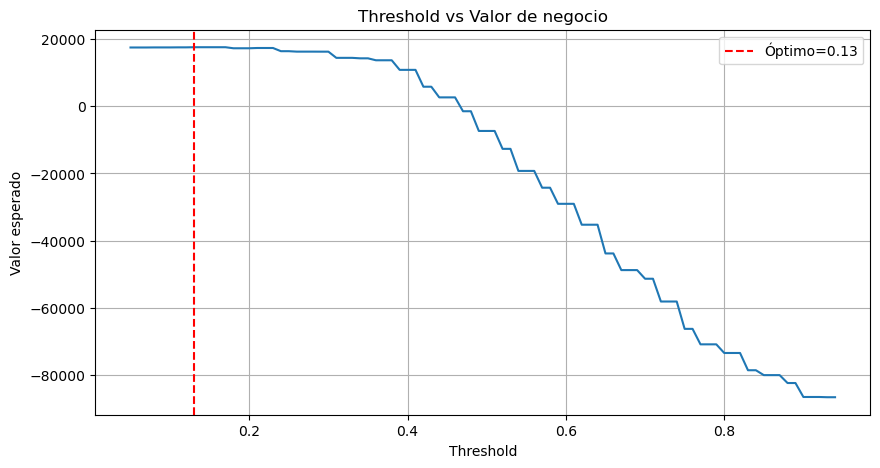

In [60]:
plt.figure(figsize=(10,5))

plt.plot(
    df_thresholds["threshold"],
    df_thresholds["valor"]
)

plt.axvline(
    best["threshold"],
    color="red",
    linestyle="--",
    label=f'Óptimo={best["threshold"]:.2f}'
)

plt.xlabel("Threshold")
plt.ylabel("Valor esperado")
plt.title("Threshold vs Valor de negocio")

plt.legend()
plt.grid(True)

plt.show()

El threshold óptimo coincide con el mayo valor economico posible

Gain Curve

In [65]:
order = np.argsort(-y_proba)

y_sorted = y_test.values[order]

cum_pos = np.cumsum(y_sorted)

total_pos = y_test.sum()

x = np.arange(1, len(y_test)+1) / len(y_test)

y_gain = cum_pos / total_pos

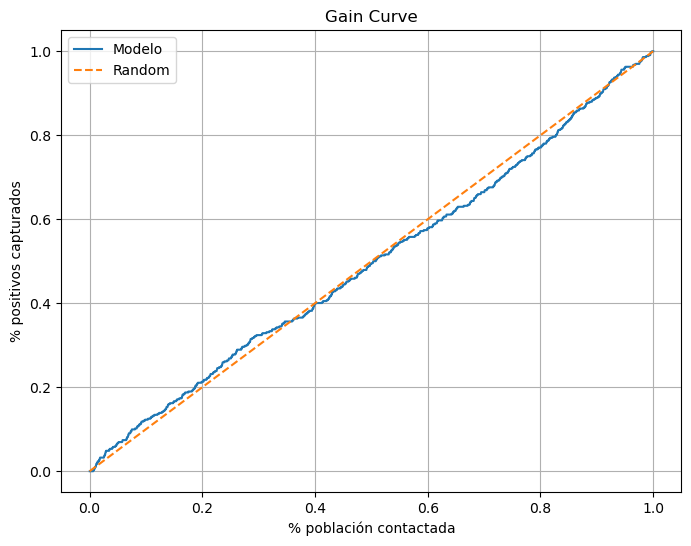

In [66]:
plt.figure(figsize=(8,6))

plt.plot(x, y_gain, label="Modelo")
plt.plot([0,1],[0,1], "--", label="Random")

plt.xlabel("% población contactada")
plt.ylabel("% positivos capturados")

plt.title("Gain Curve")

plt.legend()
plt.grid(True)

plt.show()

Lift

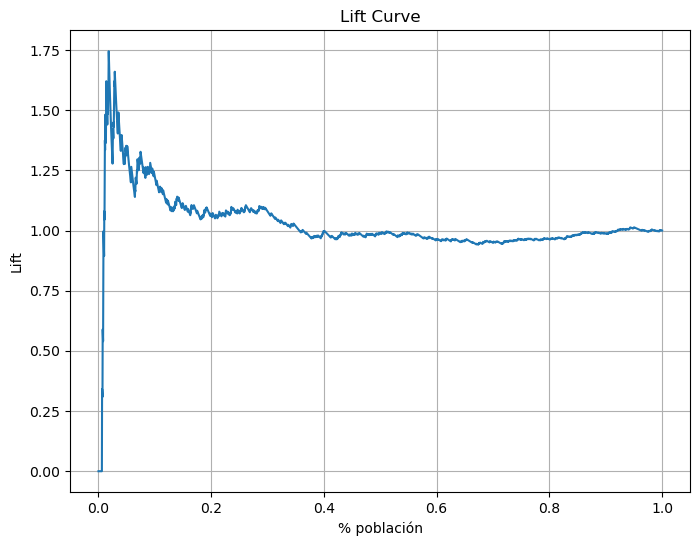

In [67]:
lift = y_gain / x

plt.figure(figsize=(8,6))

plt.plot(x, lift)

plt.xlabel("% población")
plt.ylabel("Lift")

plt.title("Lift Curve")

plt.grid(True)

plt.show()

Impacto anual

In [68]:
impacto_anual = best["valor"]

print(f"Impacto económico anual estimado: USD {impacto_anual:,.2f}")

Impacto económico anual estimado: USD 17,520.00


Supuestos de negocio
- Cada empleado retenido correctamente genera un ahorro estimado de USD 150.
- Una falsa intervención cuesta aproximadamente USD 20.
- No detectar una fuga representa una pérdida promedio de USD 200.
- El dataset representa comportamiento anual.